# Logo Detection Training - Colab + Kaggle Only

Run this notebook in **Google Colab** with GPU enabled. It uses Kaggle-hosted datasets only for training data: LogoDet-3K, Logo-2K+, and small Kaggle fallback logo datasets. No Roboflow project or manual data upload is required.

You only need to paste your Kaggle credentials in the credentials cell. Google Drive is mounted so trained weights, YAML, class reports, and plots are saved under `MyDrive/logo_detection_colab_outputs`.

Primary public sources used by this notebook:

- `lyly99/logodet3k` - LogoDet-3K object-detection dataset
- `siddharthkumarsah/logo-dataset-2341-classes-and-167140-images` - Logo-2K+ classification logo dataset
- `programmer3/brand-logos-and-icons-dataset` - public-domain fallback logos/icons
- `momotabanerjee/brand-logo-recognition-dataset` - public-domain fallback brand logo images
- `adnanpen/logo-dataset` - fallback logo images

Detection labels are taken from real detection annotations when available. Classification-only logo folders are converted to full-image logo boxes so YOLO can still learn the requested brand classes.

Removed from the training class list because the public Kaggle sources returned zero or too few usable samples: `micromax`, `videocon`, `daikin`, `nova_launcher`, `microsoft_launcher`.


This version follows the useful part of LogoHunter's design philosophy: evaluate detection quality separately from brand identification. Since this notebook trains a multi-class YOLO detector directly, it reports per-class precision/recall/F1/AP and overall mAP/precision/recall after validation.


In [1]:
# CELL 1 | Colab runtime, Drive mount, and dependency install
import os, sys, subprocess, textwrap

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Not running in Colab; local dry-run mode for syntax/JSON checks.')

# GPU check: warn instead of hard-fail so setup cells can still run.
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
    print('GPU:', r.stdout.strip() if r.returncode == 0 else 'No GPU visible. In Colab: Runtime > Change runtime type > T4 GPU')
except Exception as exc:
    print('GPU check skipped:', exc)

# Colab installs. The apt package is for Logo-2K+ .rar archives.
if IN_COLAB:
    !apt-get -qq update
    !apt-get -qq install -y unrar tesseract-ocr
    !pip install -q --upgrade pip
    !pip install -q "ultralytics>=8.3.0" kaggle pyyaml opencv-python-headless pillow pandas matplotlib tqdm pytesseract

import torch
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())


Mounted at /content/drive
GPU: Tesla T4, 15360 MiB
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.9 MB/s eta 0:00:00
Python: 3.12.13
PyTorch: 2.10.0+cu128 | CUDA: True


In [2]:
# CELL 2 | Kaggle credentials
# Option A: paste a full kaggle.json dict below.
# Option B: paste username/key separately.
# Do not commit/share this notebook after pasting real credentials.

import os, json, stat
from pathlib import Path

KAGGLE_JSON = {
    "username": "PASTE_KAGGLE_USERNAME_HERE",
    "key": "PASTE_KAGGLE_KEY_HERE"
}

# If you use a Kaggle API token style in your environment, this notebook also honors it.
KAGGLE_USERNAME = os.environ.get('KAGGLE_USERNAME', KAGGLE_JSON.get('username', ''))
KAGGLE_KEY = os.environ.get('KAGGLE_KEY', KAGGLE_JSON.get('key', ''))

if not KAGGLE_USERNAME or 'PASTE_' in KAGGLE_USERNAME or not KAGGLE_KEY or 'PASTE_' in KAGGLE_KEY:
    raise RuntimeError('Paste your Kaggle username and key in this cell before running dataset download.')

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY
kaggle_dir = Path('/root/.kaggle')
kaggle_dir.mkdir(parents=True, exist_ok=True)
with open(kaggle_dir / 'kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod(kaggle_dir / 'kaggle.json', 0o600)

!kaggle datasets list -s logodet3k | head -5
print('Kaggle credentials installed.')


RuntimeError: Paste your Kaggle username and key in this cell before running dataset download.

In [3]:
# CELL 2 | Kaggle credentials
# Option A: paste a full kaggle.json dict below.
# Option B: paste username/key separately.
# Do not commit/share this notebook after pasting real credentials.

import os, json, stat
from pathlib import Path

KAGGLE_JSON = {
    "username": "ishithab",
    "key": "efe1dff0649a0cdba0ba79f94696156a"
}

# If you use a Kaggle API token style in your environment, this notebook also honors it.
KAGGLE_USERNAME = os.environ.get('KAGGLE_USERNAME', KAGGLE_JSON.get('username', ''))
KAGGLE_KEY = os.environ.get('KAGGLE_KEY', KAGGLE_JSON.get('key', ''))

if not KAGGLE_USERNAME or 'PASTE_' in KAGGLE_USERNAME or not KAGGLE_KEY or 'PASTE_' in KAGGLE_KEY:
    raise RuntimeError('Paste your Kaggle username and key in this cell before running dataset download.')

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY
kaggle_dir = Path('/root/.kaggle')
kaggle_dir.mkdir(parents=True, exist_ok=True)
with open(kaggle_dir / 'kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod(kaggle_dir / 'kaggle.json', 0o600)

!kaggle datasets list -s logodet3k | head -5
print('Kaggle credentials installed.')


ref                              title                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------  ----------------  ----------  --------------------------  -------------  ---------  ---------------  
powerrangersss/logodet3k-top100  LogoDet3k_Top100   298920581  2025-12-23 17:29:48.053000              4          0  0.1875           
ojas025/logodet3k-resume         logodet3k-resume    80290970  2026-04-27 14:18:39.147000              1          0  0.25             
Kaggle credentials installed.


In [4]:
# CELL 3 | Target logos, paths, and helpers
import os, re, cv2, json, yaml, glob, shutil, random, hashlib, subprocess, zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import numpy as np
from PIL import Image, ImageOps

random.seed(42)

# Requested phone / electronics brands. Cell 6 will automatically keep only
# classes with enough usable Kaggle samples and remap labels before training.
REQUESTED_LOGO_CLASSES = [
    'motorola', 'samsung', 'oppo', 'vivo', 'htc', 'sony', 'nokia',
    'honor', 'huawei', 'asus', 'lg', 'oneplus', 'apple', 'micromax',
    'lenovo', 'gionee', 'infocus', 'ten_or', 'lava', 'panasonic',
    'intex', 'jio', 'reliance', 'blackberry', 'google',
]
LOGO_CLASSES = REQUESTED_LOGO_CLASSES.copy()
CLASS_TO_IDX = {name: i for i, name in enumerate(LOGO_CLASSES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

ALIASES = {
    'motorola': ['motorola', 'moto', 'motorola mobility'],
    'samsung': ['samsung', 'samsung electronics', 'samsung mobile'],
    'oppo': ['oppo'],
    'vivo': ['vivo'],
    'htc': ['htc', 'high tech computer'],
    'sony': ['sony', 'sony_logo', 'sony electronics', 'sony mobile'],
    'nokia': ['nokia'],
    'honor': ['honor', 'hihonor'],
    'huawei': ['huawei'],
    'asus': ['asus', 'asus mobile', 'asus_rog', 'rog phone'],
    'lg': ['lg', 'lg_logo', 'lg electronics', 'life good', 'lifesgood'],
    'oneplus': ['oneplus', 'one plus', '1plus', '1 plus'],
    'apple': ['apple', 'apple inc', 'iphone', 'ios'],
    'micromax': ['micromax', 'micro max'],
    'lenovo': ['lenovo'],
    'gionee': ['gionee'],
    'infocus': ['infocus', 'in focus'],
    'ten_or': ['10.or', '10 or', '10or', 'tenor', 'ten_or'],
    'lava': ['lava', 'lava mobile', 'lava mobiles'],
    'panasonic': ['panasonic'],
    'intex': ['intex', 'intex technologies'],
    'jio': ['jio', 'reliance jio', 'jiophone', 'jio phone'],
    'reliance': ['reliance', 'reliance communications', 'reliance digital'],
    'blackberry': ['blackberry', 'black berry'],
    'google': ['google', 'google pixel', 'pixel'],
}

def clean_name(value):
    value = str(value).lower()
    value = re.sub(r'[^a-z0-9]+', '_', value)
    value = re.sub(r'_+', '_', value).strip('_')
    return value

ALIAS_TO_CLASS = {}
for cls, names in ALIASES.items():
    for name in names + [cls]:
        ALIAS_TO_CLASS[clean_name(name)] = cls

def canonical_from_text(text):
    cleaned = clean_name(text)
    if cleaned in ALIAS_TO_CLASS:
        return ALIAS_TO_CLASS[cleaned]
    parts = cleaned.split('_')
    for size in range(min(4, len(parts)), 0, -1):
        for i in range(0, len(parts) - size + 1):
            candidate = '_'.join(parts[i:i+size])
            if candidate in ALIAS_TO_CLASS:
                return ALIAS_TO_CLASS[candidate]
    return None

DRIVE_OUT = Path('/content/drive/MyDrive/logo_detection_colab_outputs')
ROOT = Path('/content/logo_detection_workspace')
RAW_DIR = ROOT / 'raw'
POOL_IMG = ROOT / 'pool/images'
POOL_LBL = ROOT / 'pool/labels'
FILTERED_IMG = ROOT / 'filtered_pool/images'
FILTERED_LBL = ROOT / 'filtered_pool/labels'
YOLO_DIR = ROOT / 'yolo'
RUN_DIR = ROOT / 'runs'
OUT_DIR = ROOT / 'test_outputs'
YAML_PATH = YOLO_DIR / 'data.yaml'
CLASS_MAP_PATH = DRIVE_OUT / 'class_mapping.json'

for p in [DRIVE_OUT, RAW_DIR, POOL_IMG, POOL_LBL, FILTERED_IMG, FILTERED_LBL, YOLO_DIR, RUN_DIR, OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)
for split in ['train', 'val']:
    (YOLO_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def valid_image(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

def image_size(path):
    with Image.open(path) as im:
        return im.size

def md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

def clamp01(v):
    return max(0.0, min(1.0, float(v)))

def xyxy_to_yolo(cls_id, x1, y1, x2, y2, w, h):
    x1, x2 = sorted([max(0, min(float(x1), w)), max(0, min(float(x2), w))])
    y1, y2 = sorted([max(0, min(float(y1), h)), max(0, min(float(y2), h))])
    if x2 - x1 < 2 or y2 - y1 < 2:
        return None
    cx = ((x1 + x2) / 2) / w
    cy = ((y1 + y2) / 2) / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h
    return cls_id, clamp01(cx), clamp01(cy), clamp01(bw), clamp01(bh)

def write_label(path, anns):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        for cls_id, cx, cy, bw, bh in anns:
            f.write(f'{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')

def safe_copy_image(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    with Image.open(src) as im:
        im = ImageOps.exif_transpose(im).convert('RGB')
        im.save(dst, quality=92)

print('Requested classes:', REQUESTED_LOGO_CLASSES)
print('Workspace:', ROOT)
print('Drive outputs:', DRIVE_OUT)


Requested classes: ['motorola', 'samsung', 'oppo', 'vivo', 'htc', 'sony', 'nokia', 'honor', 'huawei', 'asus', 'lg', 'oneplus', 'apple', 'micromax', 'lenovo', 'gionee', 'infocus', 'ten_or', 'lava', 'panasonic', 'intex', 'jio', 'reliance', 'blackberry', 'google']
Workspace: /content/logo_detection_workspace
Drive outputs: /content/drive/MyDrive/logo_detection_colab_outputs


In [5]:
# CELL 4 | Download public Kaggle datasets
# LogoDet-3K is the main detection source. Logo-2K+ and public logo collections are fallbacks.

KAGGLE_DATASETS = [
    ('logodet3k', 'lyly99/logodet3k'),
    ('logo2k_plus', 'siddharthkumarsah/logo-dataset-2341-classes-and-167140-images'),
    ('brand_logos_icons', 'programmer3/brand-logos-and-icons-dataset'),
    ('brand_logo_recognition', 'momotabanerjee/brand-logo-recognition-dataset'),
    ('small_logo_dataset', 'adnanpen/logo-dataset'),
    ('famous_brand_logos', 'linkanjarad/famous-brand-logos'),
    # Older LogoHunter used Logos in the Wild as its detection source; this Kaggle mirror is included if available.
    ('logos_in_the_wild', 'balabaskar/logos-in-the-wild-dataset'),
]

DOWNLOAD_EVERYTHING = True  # Set False if you only want to redownload missing folders.

def kaggle_download(slug, dest):
    dest.mkdir(parents=True, exist_ok=True)
    marker = dest / '.download_complete'
    if marker.exists() and not DOWNLOAD_EVERYTHING:
        print(f'Skip existing: {slug}')
        return
    print(f'Downloading {slug} -> {dest}')
    cmd = ['kaggle', 'datasets', 'download', '-d', slug, '-p', str(dest), '--unzip']
    subprocess.run(cmd, check=True)
    marker.write_text(slug)

for label, slug in KAGGLE_DATASETS:
    try:
        kaggle_download(slug, RAW_DIR / label)
    except Exception as exc:
        print(f'WARNING: failed to download {slug}: {exc}')

# Unpack nested archives if Kaggle leaves .rar/.zip/.7z files inside downloaded folders.
def unpack_nested_archives(root):
    archives = [p for p in Path(root).rglob('*') if p.suffix.lower() in {'.zip', '.rar', '.7z'}]
    for archive in archives:
        target = archive.with_suffix('')
        if target.exists() and target.is_dir() and any(target.iterdir()):
            continue
        target.mkdir(parents=True, exist_ok=True)
        print('Unpacking:', archive.name)
        try:
            if archive.suffix.lower() == '.zip':
                with zipfile.ZipFile(archive) as zf:
                    zf.extractall(target)
            else:
                subprocess.run(['unrar', 'x', '-o+', str(archive), str(target) + '/'], check=False)
        except Exception as exc:
            print('WARNING: could not unpack', archive, exc)

unpack_nested_archives(RAW_DIR)
print('Download/unpack step complete.')


Download/unpack step complete.


In [6]:
# CELL 5 | Convert Kaggle data to YOLO labels
# Supports Pascal VOC XML, YOLO txt, COCO JSON where present, and classification folder/image-name fallbacks.

required_from_cell_3 = ['POOL_IMG', 'POOL_LBL', 'RAW_DIR', 'IMG_EXTS', 'CLASS_TO_IDX', 'IDX_TO_CLASS', 'canonical_from_text', 'write_label', 'safe_copy_image']
missing_from_cell_3 = [name for name in required_from_cell_3 if name not in globals()]
if missing_from_cell_3:
    raise RuntimeError('Run Cell 3 first. Missing setup variables/functions: ' + ', '.join(missing_from_cell_3))

# Clear old converted labels/images first. This matters if the class list changed.
for folder in [POOL_IMG, POOL_LBL]:
    shutil.rmtree(folder, ignore_errors=True)
    folder.mkdir(parents=True, exist_ok=True)

converted = []
skipped = Counter()
class_source_counts = Counter()
seen_hashes = set()

def add_sample(image_path, anns, source_tag):
    image_path = Path(image_path)
    if not anns or not image_path.exists() or image_path.suffix.lower() not in IMG_EXTS or not valid_image(image_path):
        skipped['bad_or_unlabeled'] += 1
        return False
    digest = md5_file(image_path)
    label_digest = hashlib.md5(json.dumps(anns, sort_keys=True).encode()).hexdigest()
    key = digest + label_digest
    if key in seen_hashes:
        skipped['duplicates'] += 1
        return False
    seen_hashes.add(key)
    stem = f'logo_{len(converted):07d}'
    dst_img = POOL_IMG / f'{stem}.jpg'
    dst_lbl = POOL_LBL / f'{stem}.txt'
    safe_copy_image(image_path, dst_img)
    write_label(dst_lbl, anns)
    converted.append({'image': str(dst_img), 'label': str(dst_lbl), 'source': source_tag})
    for ann in anns:
        class_source_counts[(IDX_TO_CLASS[ann[0]], source_tag)] += 1
    return True

def parse_voc_xml(xml_path):
    xml_path = Path(xml_path)
    try:
        tree = ET.parse(xml_path)
    except Exception:
        return None, []
    root = tree.getroot()
    filename = root.findtext('filename')
    candidates = []
    if filename:
        candidates += list(xml_path.parent.rglob(filename))
    candidates += [xml_path.with_suffix(ext) for ext in IMG_EXTS]
    img_path = next((p for p in candidates if p.exists() and p.suffix.lower() in IMG_EXTS), None)
    if img_path is None:
        return None, []
    w, h = image_size(img_path)
    anns = []
    for obj in root.findall('.//object'):
        label = obj.findtext('name') or ''
        canon = canonical_from_text(label)
        if canon is None:
            continue
        bnd = obj.find('bndbox')
        if bnd is None:
            continue
        vals = [bnd.findtext(k) for k in ['xmin', 'ymin', 'xmax', 'ymax']]
        if any(v is None for v in vals):
            continue
        ann = xyxy_to_yolo(CLASS_TO_IDX[canon], *map(float, vals), w, h)
        if ann:
            anns.append(ann)
    return img_path, anns

def ingest_pascal_voc(root, source_tag):
    n = 0
    for xml_path in tqdm(list(Path(root).rglob('*.xml')), desc=f'VOC {source_tag}'):
        img, anns = parse_voc_xml(xml_path)
        if img and add_sample(img, anns, source_tag):
            n += 1
    return n

def infer_yolo_names(txt_path):
    # Uses nearest data.yaml/classes.txt/names.txt if one exists. Otherwise returns None.
    for parent in [txt_path.parent] + list(txt_path.parents):
        for name_file in ['data.yaml', 'dataset.yaml']:
            p = parent / name_file
            if p.exists():
                try:
                    data = yaml.safe_load(p.read_text()) or {}
                    names = data.get('names')
                    if isinstance(names, dict):
                        return {int(k): canonical_from_text(v) for k, v in names.items()}
                    if isinstance(names, list):
                        return {i: canonical_from_text(v) for i, v in enumerate(names)}
                except Exception:
                    pass
        for name_file in ['classes.txt', 'names.txt']:
            p = parent / name_file
            if p.exists():
                names = [line.strip() for line in p.read_text(errors='ignore').splitlines() if line.strip()]
                return {i: canonical_from_text(v) for i, v in enumerate(names)}
    return None

def ingest_yolo_txt(root, source_tag):
    n = 0
    for txt_path in tqdm(list(Path(root).rglob('*.txt')), desc=f'YOLO {source_tag}'):
        txt_path = Path(txt_path)
        if txt_path.name.lower() in {'classes.txt', 'names.txt'}:
            continue
        img = next((txt_path.with_suffix(ext) for ext in IMG_EXTS if txt_path.with_suffix(ext).exists()), None)
        if img is None:
            continue
        names = infer_yolo_names(txt_path)
        anns = []
        for line in txt_path.read_text(errors='ignore').splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            try:
                raw_id = int(float(parts[0]))
                coords = list(map(float, parts[1:5]))
            except Exception:
                continue
            canon = names.get(raw_id) if names else (IDX_TO_CLASS.get(raw_id) if raw_id < len(LOGO_CLASSES) else None)
            if canon not in CLASS_TO_IDX:
                continue
            anns.append((CLASS_TO_IDX[canon], *coords))
        if add_sample(img, anns, source_tag):
            n += 1
    return n

def ingest_coco_json(root, source_tag):
    n = 0
    for json_path in tqdm(list(Path(root).rglob('*.json')), desc=f'COCO {source_tag}'):
        try:
            data = json.loads(json_path.read_text(errors='ignore'))
        except Exception:
            continue
        if not isinstance(data, dict) or 'images' not in data or 'annotations' not in data or 'categories' not in data:
            continue
        cat_map = {c.get('id'): canonical_from_text(c.get('name', '')) for c in data.get('categories', [])}
        img_map = {img.get('id'): img for img in data.get('images', [])}
        anns_by_img = defaultdict(list)
        for ann in data.get('annotations', []):
            canon = cat_map.get(ann.get('category_id'))
            if canon not in CLASS_TO_IDX or 'bbox' not in ann:
                continue
            img_info = img_map.get(ann.get('image_id'))
            if not img_info:
                continue
            x, y, bw, bh = ann['bbox']
            w, h = img_info.get('width'), img_info.get('height')
            if not w or not h:
                continue
            yolo_ann = xyxy_to_yolo(CLASS_TO_IDX[canon], x, y, x + bw, y + bh, w, h)
            if yolo_ann:
                anns_by_img[ann.get('image_id')].append(yolo_ann)
        for img_id, anns in anns_by_img.items():
            rel = img_map[img_id].get('file_name', '')
            candidates = list(json_path.parent.rglob(Path(rel).name))
            img_path = next((p for p in candidates if p.suffix.lower() in IMG_EXTS), None)
            if img_path and add_sample(img_path, anns, source_tag):
                n += 1
    return n

def class_from_path(image_path):
    image_path = Path(image_path)
    candidates = [image_path.stem] + [p.name for p in image_path.parents[:4]]
    for text in candidates:
        canon = canonical_from_text(text)
        if canon in CLASS_TO_IDX:
            return canon
    return None

def ingest_classification_folders(root, source_tag, max_per_class=800):
    per_class = Counter()
    n = 0
    images = [p for p in Path(root).rglob('*') if p.suffix.lower() in IMG_EXTS]
    for img in tqdm(images, desc=f'CLS {source_tag}'):
        canon = class_from_path(img)
        if canon not in CLASS_TO_IDX:
            continue
        if per_class[canon] >= max_per_class:
            continue
        ann = (CLASS_TO_IDX[canon], 0.5, 0.5, 1.0, 1.0)
        if add_sample(img, [ann], source_tag):
            per_class[canon] += 1
            n += 1
    return n

for label, _slug in KAGGLE_DATASETS:
    root = RAW_DIR / label
    if not root.exists():
        continue
    print(f'\n--- Ingesting {label} ---')
    print('VOC:', ingest_pascal_voc(root, label))
    print('COCO:', ingest_coco_json(root, label))
    print('YOLO:', ingest_yolo_txt(root, label))
    print('Classification fallback:', ingest_classification_folders(root, label))

# Synthetic small-logo augmentation.
# Why: many Kaggle fallback sets are clean logo images with full-image boxes, but real videos have tiny logos
# on phones/screens/cards. These composites teach the detector to find small logo regions in cluttered frames.
def random_background(size=640):
    base = np.random.randint(165, 245, (size, size, 3), dtype=np.uint8)
    for _ in range(random.randint(2, 6)):
        x1, y1 = random.randint(0, size-1), random.randint(0, size-1)
        x2, y2 = random.randint(0, size-1), random.randint(0, size-1)
        color = tuple(int(v) for v in np.random.randint(40, 230, 3))
        cv2.rectangle(base, (min(x1,x2), min(y1,y2)), (max(x1,x2), max(y1,y2)), color, -1)
    if random.random() < 0.5:
        base = cv2.GaussianBlur(base, (5, 5), 0)
    return Image.fromarray(cv2.cvtColor(base, cv2.COLOR_BGR2RGB)).convert('RGBA')

def read_single_full_image_label(lbl_path):
    lines = [line.split() for line in Path(lbl_path).read_text().splitlines() if line.strip()]
    if len(lines) != 1 or len(lines[0]) < 5:
        return None
    cls_id = int(float(lines[0][0])); cx, cy, bw, bh = map(float, lines[0][1:5])
    if bw < 0.90 or bh < 0.90:
        return None
    return cls_id

def add_synthetic_small_logo_samples(copies_per_source=3, max_sources_per_class=250, canvas=640):
    per_class_sources = Counter()
    sources = []
    for img in sorted(POOL_IMG.glob('*.jpg')):
        lbl = POOL_LBL / f'{img.stem}.txt'
        if not lbl.exists():
            continue
        cls_id = read_single_full_image_label(lbl)
        if cls_id is None or cls_id not in IDX_TO_CLASS:
            continue
        cls_name = IDX_TO_CLASS[cls_id]
        if per_class_sources[cls_name] >= max_sources_per_class:
            continue
        per_class_sources[cls_name] += 1
        sources.append((img, cls_id))

    made = 0
    for img_path, cls_id in tqdm(sources, desc='Synthetic small-logo composites'):
        try:
            logo = Image.open(img_path).convert('RGBA')
        except Exception:
            continue
        logo = ImageOps.exif_transpose(logo)
        for _ in range(copies_per_source):
            bg = random_background(canvas)
            scale = random.uniform(0.045, 0.24)
            max_w = int(canvas * scale)
            ratio = min(max_w / max(1, logo.width), max_w / max(1, logo.height))
            new_w = max(12, int(logo.width * ratio))
            new_h = max(12, int(logo.height * ratio))
            patch = logo.resize((new_w, new_h), Image.LANCZOS)
            if random.random() < 0.35:
                patch = patch.rotate(random.uniform(-8, 8), expand=True, resample=Image.BICUBIC)
            x = random.randint(0, max(0, canvas - patch.width))
            y = random.randint(0, max(0, canvas - patch.height))
            bg.alpha_composite(patch, (x, y))
            if random.random() < 0.35:
                bg = bg.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.8)))
            stem = f'synth_{made:07d}'
            out_img = POOL_IMG / f'{stem}.jpg'
            out_lbl = POOL_LBL / f'{stem}.txt'
            bg.convert('RGB').save(out_img, quality=90)
            ann = xyxy_to_yolo(cls_id, x, y, x + patch.width, y + patch.height, canvas, canvas)
            if ann:
                write_label(out_lbl, [ann])
                class_source_counts[(IDX_TO_CLASS[cls_id], 'synthetic_small_logo')] += 1
                made += 1
    return made

from PIL import ImageFilter
synthetic_count = add_synthetic_small_logo_samples(copies_per_source=3)
print('Synthetic small-logo samples added:', synthetic_count)

print('\nConverted samples:', len(list(POOL_IMG.glob('*.jpg'))))
print('Skipped:', dict(skipped))



--- Ingesting logodet3k ---


VOC logodet3k:   0%|          | 0/158654 [00:00<?, ?it/s]

VOC: 589


COCO logodet3k: 0it [00:00, ?it/s]

COCO: 0


...

YOLO: 0


CLS logos_in_the_wild: 0it [00:00, ?it/s]

Classification fallback: 0


Synthetic small-logo composites:   0%|          | 0/2151 [00:00<?, ?it/s]

Synthetic small-logo samples added: 6453

Converted samples: 9841
Skipped: {'bad_or_unlabeled': 157971, 'duplicates': 630}


In [7]:
# CELL 6 | Filter usable classes, remap labels, split train/val, and write YAML
TRAIN_SPLIT = 0.85
MIN_IMAGES_PER_CLASS = 5

# Count original requested-class objects in the unfiltered pool.
source_by_class = defaultdict(Counter)
for (cls, source), count in class_source_counts.items():
    source_by_class[cls][source] += count

raw_counts = Counter()
for lbl in POOL_LBL.glob('*.txt'):
    for line in lbl.read_text().splitlines():
        parts = line.split()
        if parts:
            cls_id = int(parts[0])
            if cls_id in IDX_TO_CLASS:
                raw_counts[IDX_TO_CLASS[cls_id]] += 1

KEPT_CLASSES = [cls for cls in REQUESTED_LOGO_CLASSES if raw_counts[cls] >= MIN_IMAGES_PER_CLASS]
REMOVED_CLASSES = [cls for cls in REQUESTED_LOGO_CLASSES if cls not in KEPT_CLASSES]
if not KEPT_CLASSES:
    raise RuntimeError('No requested classes have enough Kaggle samples. Lower MIN_IMAGES_PER_CLASS or add more public Kaggle datasets.')

OLD_CLASS_TO_NEW = {CLASS_TO_IDX[cls]: new_id for new_id, cls in enumerate(KEPT_CLASSES)}
LOGO_CLASSES = KEPT_CLASSES
CLASS_TO_IDX = {name: i for i, name in enumerate(LOGO_CLASSES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

# Clear filtered pool and splits.
for folder in [FILTERED_IMG, FILTERED_LBL]:
    shutil.rmtree(folder, ignore_errors=True)
    folder.mkdir(parents=True, exist_ok=True)
for split in ['train', 'val']:
    for sub in ['images', 'labels']:
        folder = YOLO_DIR / split / sub
        shutil.rmtree(folder, ignore_errors=True)
        folder.mkdir(parents=True, exist_ok=True)

# Remap labels. If an image only contains removed classes, drop it.
kept_image_count = 0
for img in sorted(POOL_IMG.glob('*.jpg')):
    lbl = POOL_LBL / f'{img.stem}.txt'
    if not lbl.exists():
        continue
    new_anns = []
    for line in lbl.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        old_id = int(parts[0])
        if old_id not in OLD_CLASS_TO_NEW:
            continue
        new_anns.append((OLD_CLASS_TO_NEW[old_id], *map(float, parts[1:5])))
    if not new_anns:
        continue
    stem = f'logo_{kept_image_count:07d}'
    shutil.copy2(img, FILTERED_IMG / f'{stem}.jpg')
    write_label(FILTERED_LBL / f'{stem}.txt', new_anns)
    kept_image_count += 1

pool_images = sorted(FILTERED_IMG.glob('*.jpg'))
random.shuffle(pool_images)
cut = int(len(pool_images) * TRAIN_SPLIT)
for split, subset in [('train', pool_images[:cut]), ('val', pool_images[cut:])]:
    for img in subset:
        lbl = FILTERED_LBL / f'{img.stem}.txt'
        if not lbl.exists():
            continue
        shutil.copy2(img, YOLO_DIR / split / 'images' / img.name)
        shutil.copy2(lbl, YOLO_DIR / split / 'labels' / lbl.name)

data_yaml = {
    'path': str(YOLO_DIR),
    'train': 'train/images',
    'val': 'val/images',
    'nc': len(LOGO_CLASSES),
    'names': LOGO_CLASSES,
}
YAML_PATH.write_text(yaml.safe_dump(data_yaml, sort_keys=False))

counts = Counter()
for lbl in FILTERED_LBL.glob('*.txt'):
    for line in lbl.read_text().splitlines():
        parts = line.split()
        if parts:
            cls_id = int(parts[0])
            if cls_id in IDX_TO_CLASS:
                counts[IDX_TO_CLASS[cls_id]] += 1

coverage = []
print('Kept classes for training:')
for cls in LOGO_CLASSES:
    row = {'class': cls, 'objects': counts[cls], 'raw_requested_objects': raw_counts[cls], 'sources': dict(source_by_class[cls])}
    coverage.append(row)
    print(f'{cls:16s} {counts[cls]:5d} objects | sources: {dict(source_by_class[cls])}')

print('\nRemoved because public Kaggle sources had fewer than', MIN_IMAGES_PER_CLASS, 'objects:')
print(', '.join(REMOVED_CLASSES) if REMOVED_CLASSES else 'None')

report = {
    'requested_classes': REQUESTED_LOGO_CLASSES,
    'kept_classes': LOGO_CLASSES,
    'removed_classes': REMOVED_CLASSES,
    'min_images_per_class': MIN_IMAGES_PER_CLASS,
    'coverage': coverage,
}
(DRIVE_OUT / 'class_coverage_report.json').write_text(json.dumps(report, indent=2))
CLASS_MAP_PATH.write_text(json.dumps({'names': LOGO_CLASSES, 'removed': REMOVED_CLASSES}, indent=2))
shutil.copy2(YAML_PATH, DRIVE_OUT / 'data.yaml')

print('\nTrain images:', len(list((YOLO_DIR / 'train/images').glob('*.jpg'))))
print('Val images:', len(list((YOLO_DIR / 'val/images').glob('*.jpg'))))
print('YAML:', YAML_PATH)
print('Class mapping:', CLASS_MAP_PATH)


Kept classes for training:
motorola           368 objects | sources: {'logo2k_plus': 85, 'brand_logos_icons': 7, 'synthetic_small_logo': 276}
samsung            868 objects | sources: {'logo2k_plus': 92, 'brand_logos_icons': 6, 'small_logo_dataset': 21, 'famous_brand_logos': 98, 'synthetic_small_logo': 651}
oppo               360 objects | sources: {'logo2k_plus': 61, 'brand_logos_icons': 2, 'small_logo_dataset': 27, 'synthetic_small_logo': 270}
htc                622 objects | sources: {'logodet3k': 75, 'logo2k_plus': 85, 'brand_logos_icons': 3, 'small_logo_dataset': 21, 'synthetic_small_logo': 438}
sony               484 objects | sources: {'logo2k_plus': 98, 'brand_logos_icons': 6, 'small_logo_dataset': 17, 'synthetic_small_logo': 363}
nokia              452 objects | sources: {'logo2k_plus': 92, 'small_logo_dataset': 21, 'synthetic_small_logo': 339}
huawei             436 objects | sources: {'logo2k_plus': 82, 'small_logo_dataset': 27, 'synthetic_small_logo': 327}
asus             

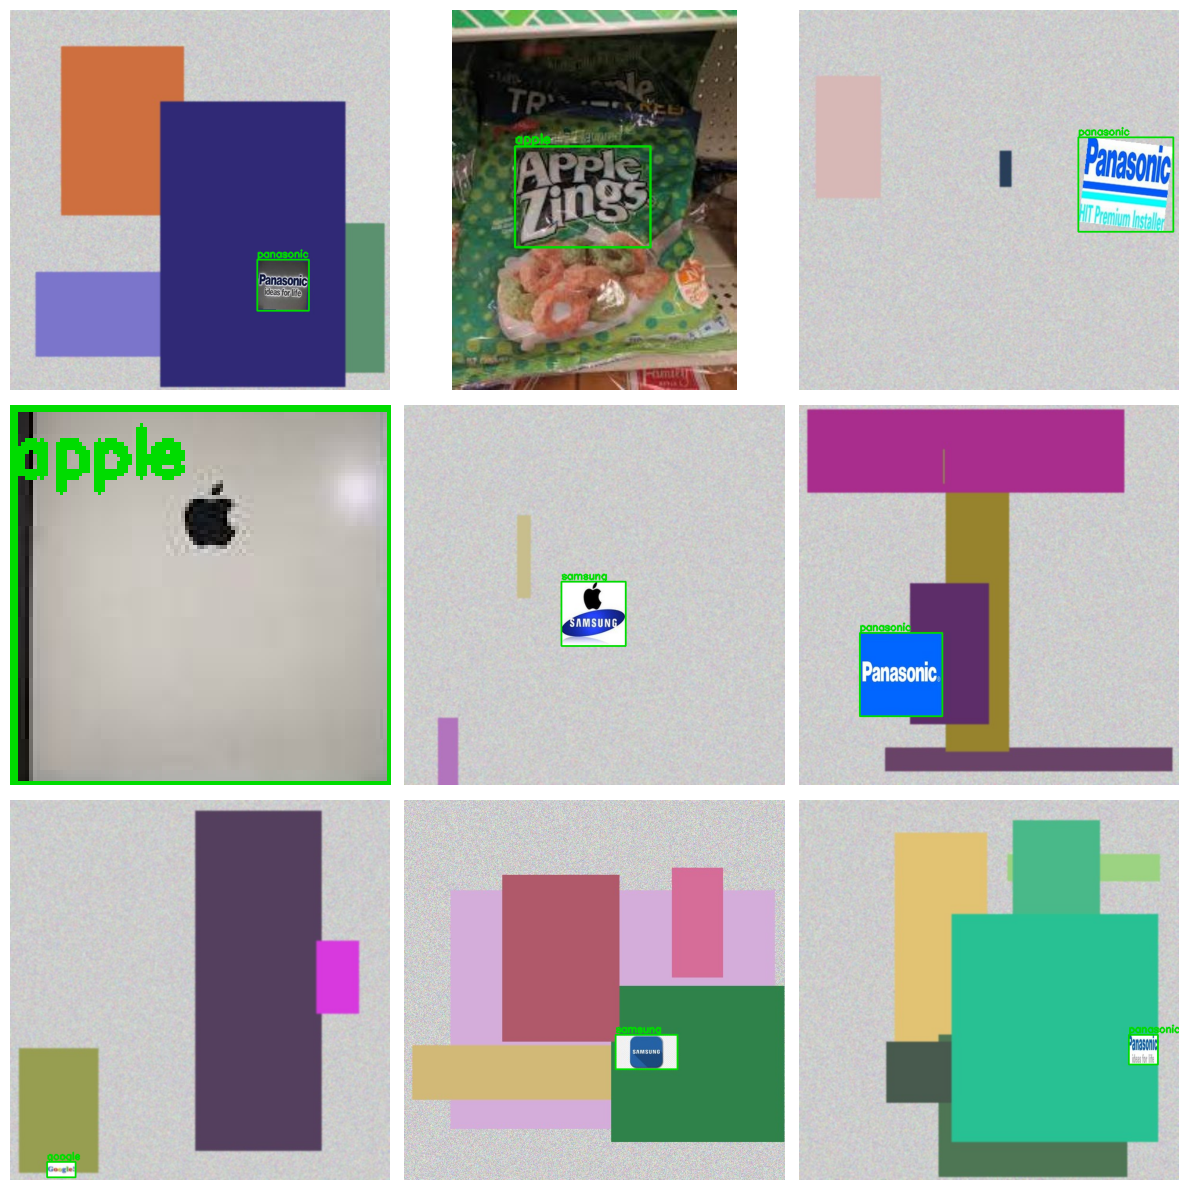

In [8]:
# CELL 7 | Quick dataset preview
import matplotlib.pyplot as plt

def draw_yolo_labels(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    for line in Path(lbl_path).read_text().splitlines():
        cls_id, cx, cy, bw, bh = map(float, line.split()[:5])
        x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 220, 0), 2)
        cv2.putText(img, IDX_TO_CLASS[int(cls_id)], (x1, max(18, y1-4)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 220, 0), 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

sample_imgs = random.sample(sorted((YOLO_DIR / 'train/images').glob('*.jpg')), min(9, len(list((YOLO_DIR / 'train/images').glob('*.jpg')))))
plt.figure(figsize=(12, 12))
for i, img in enumerate(sample_imgs):
    plt.subplot(3, 3, i + 1)
    plt.imshow(draw_yolo_labels(img, YOLO_DIR / 'train/labels' / f'{img.stem}.txt'))
    plt.axis('off')
plt.tight_layout()
plt.show()


In [9]:
# CELL 8 | Train YOLOv8 logo detector
from ultralytics import YOLO
import torch, os, shutil

EPOCHS = 60
IMGSZ = 768
BATCH = 8  # T4-safe default at 768 imgsz. Use 4 if Colab runs out of memory.
MODEL_SIZE = 'yolov8s.pt'  # Stronger than nano for tiny logos; use yolov8n.pt if you need faster training.

model = YOLO(MODEL_SIZE)
results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    patience=12,
    imgsz=IMGSZ,
    batch=BATCH,
    workers=2,
    device=0 if torch.cuda.is_available() else 'cpu',
    project=str(RUN_DIR),
    name='logo_detector',
    exist_ok=True,
    amp=True,
    verbose=True,
    scale=0.9,
    translate=0.15,
    degrees=8,
    mosaic=0.7,
    mixup=0.08,
    copy_paste=0.15,
    close_mosaic=10,
)

BEST_WEIGHTS = RUN_DIR / 'logo_detector/weights/best.pt'
LAST_WEIGHTS = RUN_DIR / 'logo_detector/weights/last.pt'
if not BEST_WEIGHTS.exists():
    BEST_WEIGHTS = LAST_WEIGHTS
print('Weights:', BEST_WEIGHTS)
shutil.copy2(BEST_WEIGHTS, DRIVE_OUT / 'best_logo_detector.pt')
print('Saved to Drive:', DRIVE_OUT / 'best_logo_detector.pt')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/logo_detection_workspace/yolo/data.yaml, degrees=8, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7,

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,132,163 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1064.0±1034.2 MB/s, size: 55.7 KB)
val: Scanning /content/logo_detection_workspace/yolo/val/labels.cache... 1477 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1477/1477 476.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 185/185 6.2it/s 29.6s
                   all       1477       1490      0.895      0.897      0.953       0.93
              motorola         52         52      0.958      0.883      0.936      0.915
               samsung        149        149       0.94      0.946      0.976      0.962
                  oppo         60         60      0.939      0.867      0.958      0.941
                   htc         83         83      0.912      0.952      0.977      0.951
                  s

,class,precision,recall,f1,ap50,ap50_95
0,motorola,0.958248,0.882769,0.918961,0.935657,0.915298
1,samsung,0.940003,0.946360,0.943171,0.976327,0.962475
2,oppo,0.939213,0.866667,0.901483,0.958235,0.940529
3,htc,0.911551,0.951807,0.931244,0.977337,0.951317
4,sony,0.937484,0.911765,0.924446,0.966960,0.941170
5,nokia,0.854902,0.950000,0.899945,0.972783,0.952830
6,huawei,0.983363,0.953387,0.968143,0.973489,0.966286
7,asus,0.799307,0.842975,0.820561,0.931038,0.871330
8,lg,0.952151,0.984127,0.967875,0.992360,0.987577
9,apple,0.757340,0.828023,0.791106,0.894635,0.830242


Saved per-class metrics: /content/drive/MyDrive/logo_detection_colab_outputs/per_class_metrics.csv
Overall metrics: {
  "overall_precision": 0.8945263586545037,
  "overall_recall": 0.8972218737448985,
  "overall_map50": 0.9531074238767173,
  "overall_map50_95": 0.9297042280565301
}
Saved overall metrics: /content/drive/MyDrive/logo_detection_colab_outputs/overall_metrics.json


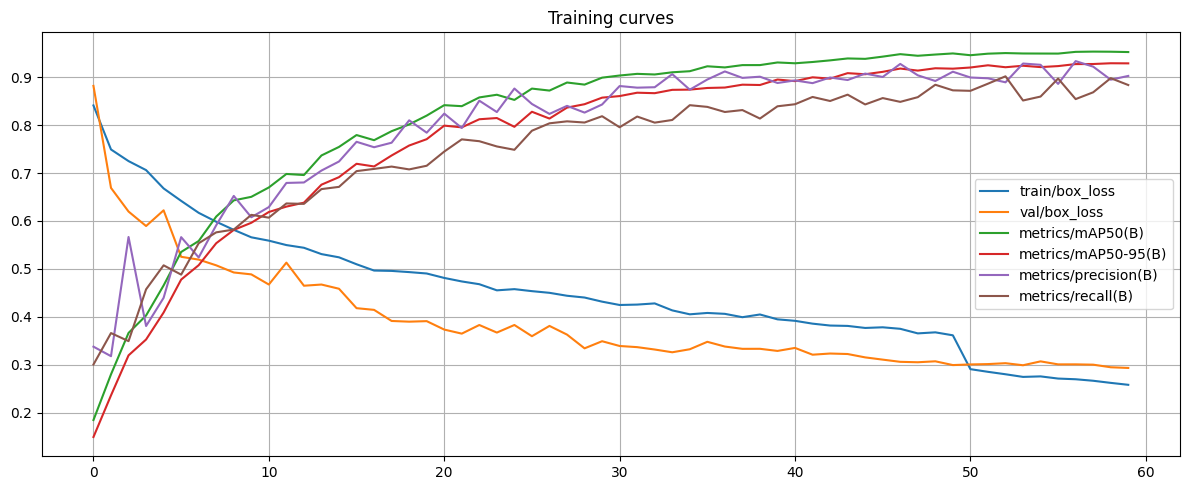

Saved curves: /content/drive/MyDrive/logo_detection_colab_outputs/training_curves.png


In [10]:
# CELL 9 | Validate, plot curves, and compute per-class metrics
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import shutil

val_model = YOLO(str(BEST_WEIGHTS))
metrics = val_model.val(data=str(YAML_PATH), imgsz=IMGSZ, batch=BATCH, plots=True)
print(metrics)

# Ultralytics exposes detection metrics as precision, recall, AP50, AP50-95 per class.
rows = []
try:
    box = metrics.box
    maps50 = getattr(box, 'ap50', None)
    maps = getattr(box, 'maps', None)
    precision = getattr(box, 'p', None)
    recall = getattr(box, 'r', None)
    for i, name in enumerate(LOGO_CLASSES):
        p = float(precision[i]) if precision is not None and len(precision) > i else None
        r = float(recall[i]) if recall is not None and len(recall) > i else None
        f1 = (2 * p * r / (p + r)) if p is not None and r is not None and (p + r) else None
        rows.append({
            'class': name,
            'precision': p,
            'recall': r,
            'f1': f1,
            'ap50': float(maps50[i]) if maps50 is not None and len(maps50) > i else None,
            'ap50_95': float(maps[i]) if maps is not None and len(maps) > i else None,
        })
except Exception as exc:
    print('Could not read per-class metric arrays:', exc)

per_class_df = pd.DataFrame(rows)
if len(per_class_df):
    display(per_class_df)
    per_class_path = DRIVE_OUT / 'per_class_metrics.csv'
    per_class_df.to_csv(per_class_path, index=False)
    print('Saved per-class metrics:', per_class_path)

# For object detection, the closest honest "overall accuracy" is the detection summary.
# This follows the LogoHunter idea of separating detection quality from brand matching:
# report mAP/precision/recall overall, not a single classification-only score.
overall = {
    'overall_precision': float(getattr(metrics.box, 'mp', 0.0)),
    'overall_recall': float(getattr(metrics.box, 'mr', 0.0)),
    'overall_map50': float(getattr(metrics.box, 'map50', 0.0)),
    'overall_map50_95': float(getattr(metrics.box, 'map', 0.0)),
}
overall_path = DRIVE_OUT / 'overall_metrics.json'
overall_path.write_text(json.dumps(overall, indent=2))
print('Overall metrics:', json.dumps(overall, indent=2))
print('Saved overall metrics:', overall_path)

csv_path = RUN_DIR / 'logo_detector/results.csv'
if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    cols = [c for c in ['train/box_loss', 'val/box_loss', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)'] if c in df.columns]
    ax = df[cols].plot(figsize=(12, 5), grid=True, title='Training curves')
    fig = ax.get_figure()
    fig.tight_layout()
    curves_path = DRIVE_OUT / 'training_curves.png'
    fig.savefig(curves_path, dpi=140)
    plt.show()
    shutil.copy2(csv_path, DRIVE_OUT / 'results.csv')
    print('Saved curves:', curves_path)


In [11]:
# CELL 10 | Video-first inference with object crops, tiling, temporal smoothing, and OCR fallback
from ultralytics import YOLO
from pathlib import Path
import cv2, time, json, math, re, shutil
import numpy as np
import pandas as pd
from IPython.display import display, Image as IPyImage, HTML
from base64 import b64encode

try:
    import pytesseract
    OCR_AVAILABLE = True
except Exception:
    OCR_AVAILABLE = False

# Brand text patterns for OCR fallback. OCR is not used as the main detector; it is a backup signal.
OCR_KEYWORDS = {
    'motorola': ['motorola', 'moto'], 'samsung': ['samsung'], 'oppo': ['oppo'], 'vivo': ['vivo'],
    'htc': ['htc'], 'sony': ['sony'], 'nokia': ['nokia'], 'honor': ['honor'], 'huawei': ['huawei'],
    'asus': ['asus'], 'lg': ['lg'], 'oneplus': ['oneplus', 'one plus'], 'apple': ['apple'],
    'micromax': ['micromax'], 'lenovo': ['lenovo'], 'gionee': ['gionee'], 'infocus': ['infocus'],
    'ten_or': ['10.or', '10 or', 'tenor'], 'lava': ['lava'], 'panasonic': ['panasonic'],
    'intex': ['intex'], 'jio': ['jio'], 'reliance': ['reliance'], 'blackberry': ['blackberry'],
    'google': ['google', 'pixel'],
}
OCR_KEYWORDS = {k: v for k, v in OCR_KEYWORDS.items() if k in LOGO_CLASSES}

COCO_DEVICE_OBJECTS = {
    'cell phone', 'laptop', 'tv', 'monitor', 'keyboard', 'remote', 'book', 'sports ball',
    'bottle', 'cup', 'handbag', 'backpack', 'suitcase', 'refrigerator', 'microwave', 'oven',
}

def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a; bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area_a = max(1, (ax2 - ax1) * (ay2 - ay1))
    area_b = max(1, (bx2 - bx1) * (by2 - by1))
    return inter / (area_a + area_b - inter + 1e-6)

def nms_detections(dets, iou_thr=0.45):
    dets = sorted(dets, key=lambda d: d['confidence'], reverse=True)
    kept = []
    for det in dets:
        if all(det['label'] != k['label'] or box_iou(det['bbox'], k['bbox']) < iou_thr for k in kept):
            kept.append(det)
    return kept

def expand_box(box, w, h, pad=0.18):
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    x1 = max(0, int(x1 - bw * pad)); y1 = max(0, int(y1 - bh * pad))
    x2 = min(w, int(x2 + bw * pad)); y2 = min(h, int(y2 + bh * pad))
    return [x1, y1, x2, y2]

class LogoDetector:
    def __init__(self, weights, confidence=0.18, imgsz=768, use_object_rois=True, use_ocr=True):
        self.model = YOLO(str(weights))
        self.object_model = YOLO('yolov8n.pt') if use_object_rois else None
        self.confidence = confidence
        self.imgsz = imgsz
        self.names = self.model.names
        self.use_ocr = use_ocr and OCR_AVAILABLE

    def candidate_rois(self, frame):
        h, w = frame.shape[:2]
        rois = [{'name': 'full', 'box': [0, 0, w, h]}]

        # Tiled pass catches tiny logos without resizing the whole frame too aggressively.
        if max(w, h) >= 900:
            tile = int(min(max(512, min(w, h) * 0.65), 900))
            stride = max(256, int(tile * 0.65))
            for y in range(0, max(1, h - tile + 1), stride):
                for x in range(0, max(1, w - tile + 1), stride):
                    rois.append({'name': 'tile', 'box': [x, y, min(w, x + tile), min(h, y + tile)]})
            rois.append({'name': 'tile', 'box': [max(0, w - tile), max(0, h - tile), w, h]})

        # COCO object pass: run logo detector on likely branded objects/devices.
        if self.object_model is not None:
            try:
                obj_res = self.object_model(frame, imgsz=640, conf=0.20, verbose=False)[0]
                for box in obj_res.boxes:
                    cls_id = int(box.cls[0])
                    obj_name = obj_res.names.get(cls_id, '')
                    if obj_name not in COCO_DEVICE_OBJECTS:
                        continue
                    xyxy = [int(v) for v in box.xyxy[0].cpu().numpy().tolist()]
                    rois.append({'name': f'object:{obj_name}', 'box': expand_box(xyxy, w, h, pad=0.22)})
            except Exception as exc:
                print('Object ROI pass skipped:', exc)

        # Deduplicate near-identical ROIs.
        unique = []
        for roi in rois:
            if all(box_iou(roi['box'], u['box']) < 0.92 for u in unique):
                unique.append(roi)
        return unique

    def detect_frame(self, frame):
        detections = []
        for roi in self.candidate_rois(frame):
            x1, y1, x2, y2 = roi['box']
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            res = self.model(crop, imgsz=self.imgsz, conf=self.confidence, verbose=False)[0]
            for box in res.boxes:
                cls_id = int(box.cls[0])
                label = self.names.get(cls_id, IDX_TO_CLASS.get(cls_id, str(cls_id)))
                conf = float(box.conf[0])
                bx1, by1, bx2, by2 = [int(v) for v in box.xyxy[0].cpu().numpy().tolist()]
                detections.append({
                    'label': label,
                    'confidence': conf,
                    'bbox': [bx1 + x1, by1 + y1, bx2 + x1, by2 + y1],
                    'source': roi['name'],
                })
        return nms_detections(detections, iou_thr=0.45)

    def ocr_frame(self, frame):
        if not self.use_ocr:
            return []
        try:
            small = frame
            h, w = frame.shape[:2]
            if max(h, w) > 1280:
                scale = 1280 / max(h, w)
                small = cv2.resize(frame, (int(w * scale), int(h * scale)))
            gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
            gray = cv2.bilateralFilter(gray, 7, 50, 50)
            data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT, config='--psm 6')
            hits = []
            for text, conf, x, y, bw, bh in zip(data.get('text', []), data.get('conf', []), data.get('left', []), data.get('top', []), data.get('width', []), data.get('height', [])):
                word = str(text).strip().lower()
                if not word:
                    continue
                try:
                    c = float(conf)
                except Exception:
                    c = -1
                if c < 35:
                    continue
                for brand, keywords in OCR_KEYWORDS.items():
                    if any(k in word or word in k for k in keywords):
                        hits.append({'label': brand, 'confidence': min(0.99, c / 100), 'bbox': [x, y, x + bw, y + bh], 'source': 'ocr', 'text': word})
            return hits
        except Exception:
            return []

    def annotate(self, frame, detections, ocr_hits=None):
        out = frame.copy()
        for det in detections:
            x1, y1, x2, y2 = [int(v) for v in det['bbox']]
            color = (0, 220, 0)
            cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
            cv2.putText(out, f"{det['label']} {det['confidence']:.2f}", (x1, max(18, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        for hit in ocr_hits or []:
            x1, y1, x2, y2 = [int(v) for v in hit['bbox']]
            color = (0, 180, 255)
            cv2.rectangle(out, (x1, y1), (x2, y2), color, 1)
            cv2.putText(out, f"OCR:{hit['label']}", (x1, max(18, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        return out

    def predict_visual(self, source, include_ocr=True):
        frame = cv2.imread(str(source)) if isinstance(source, (str, Path)) else source.copy()
        t0 = time.perf_counter()
        dets = self.detect_frame(frame)
        ocr_hits = self.ocr_frame(frame) if include_ocr else []
        annotated = self.annotate(frame, dets, ocr_hits)
        payload = {
            'logo_detections': dets,
            'ocr_brand_hits': ocr_hits,
            'competition_found': bool(dets or ocr_hits),
            '_meta': {'latency_ms': round((time.perf_counter() - t0) * 1000, 1)},
        }
        return payload, annotated

    def run_image(self, image_path):
        payload, annotated = self.predict_visual(image_path, include_ocr=True)
        out_path = OUT_DIR / f'{Path(image_path).stem}_detected.jpg'
        cv2.imwrite(str(out_path), annotated)
        display(IPyImage(filename=str(out_path)))
        print(json.dumps(payload, indent=2))
        return payload, out_path

    def run_video(self, video_path, target_fps=None, slow_factor=1.0, display_width=720):
        cap = cv2.VideoCapture(str(video_path))
        src_fps = cap.get(cv2.CAP_PROP_FPS) or 30
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
        w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        process_every = 1 if target_fps is None else max(1, round(src_fps / target_fps))
        out_fps = max(1, src_fps / max(1.0, slow_factor))
        out_path = OUT_DIR / f'{Path(video_path).stem}_detected.mp4'
        csv_path = OUT_DIR / f'{Path(video_path).stem}_detections.csv'
        writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h))
        rows, last_dets, last_ocr = [], [], []
        frame_idx = 0
        while cap.isOpened():
            ok, frame = cap.read()
            if not ok:
                break
            if frame_idx % process_every == 0:
                payload, annotated = self.predict_visual(frame, include_ocr=True)
                last_dets, last_ocr = payload['logo_detections'], payload['ocr_brand_hits']
                for det in last_dets:
                    rows.append({'frame': frame_idx, 'time_sec': frame_idx / src_fps, 'type': 'logo', **det})
                for hit in last_ocr:
                    rows.append({'frame': frame_idx, 'time_sec': frame_idx / src_fps, 'type': 'ocr', **hit})
            else:
                annotated = self.annotate(frame, last_dets, last_ocr)
            writer.write(annotated)
            frame_idx += 1
            if frame_idx % 50 == 0:
                print(f'Processed {frame_idx}/{total or "?"} frames')
        cap.release(); writer.release()
        pd.DataFrame(rows).to_csv(csv_path, index=False)
        shutil.copy2(out_path, DRIVE_OUT / out_path.name)
        shutil.copy2(csv_path, DRIVE_OUT / csv_path.name)
        print('Video saved:', out_path)
        print('Detection CSV saved:', csv_path)
        data = b64encode(open(out_path, 'rb').read()).decode()
        display(HTML(f'<video controls width="{display_width}"><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>'))
        return out_path, csv_path

logo_model = LogoDetector(BEST_WEIGHTS, confidence=0.18, imgsz=IMGSZ, use_object_rois=True, use_ocr=True)
print('Video-first inference ready. OCR available:', OCR_AVAILABLE)


Video-first inference ready. OCR available: True


In [1]:
# CELL 11 | Test on an image without uploading extra training data
# This upload is only for optional testing after training, not for dataset creation.
from google.colab import files

uploaded = files.upload()
if uploaded:
    test_image = next(iter(uploaded.keys()))
    payload, out_path = logo_model.run_image(test_image)
    shutil.copy2(out_path, DRIVE_OUT / Path(out_path).name)


Saving sony tv.webp to sony tv.webp


NameError: name 'logo_model' is not defined

In [ ]:
# CELL 12 | Optional video test
from google.colab import files

uploaded = files.upload()
if uploaded:
    video_path = next(iter(uploaded.keys()))
    out_video, detection_csv = logo_model.run_video(video_path, target_fps=None, slow_factor=1.5, display_width=720)


In [ ]:
# CELL 13 | Download trained artifacts from Colab session
from google.colab import files

for path in [DRIVE_OUT / 'best_logo_detector.pt', DRIVE_OUT / 'data.yaml', DRIVE_OUT / 'class_coverage_report.json', DRIVE_OUT / 'training_curves.png', DRIVE_OUT / 'results.csv', DRIVE_OUT / 'per_class_metrics.csv', DRIVE_OUT / 'overall_metrics.json', DRIVE_OUT / 'class_mapping.json']:
    if Path(path).exists():
        files.download(str(path))
